SUPPORT VECTOR MACHINE

Task 1: Exploratory Data Analysis (EDA)

1.	Load the Mushroom dataset and perform fundamental data exploration.

In [4]:
import pandas as pd

In [5]:
df=pd.read_csv("C:\\DataScience25\\official_assignments\\SVM\\SVM\\mushroom.csv")

In [6]:
df

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,863,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1996,1160,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,...,partial,white,one,zone,yellow,numerous,waste,poisonous,6.500840,13.501957
1997,265,convex,grooves,green,yes,fishy,notched,close,narrow,pink,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020
1998,411,bell,smooth,white,no,pungent,free,close,narrow,orange,...,universal,yellow,one,cobwebby,brown,solitary,woods,poisonous,11.092703,8.423199


In [7]:
df.shape

(2000, 26)

The dataset contains 2000 rows and 26 columns.

In [9]:
df.columns

Index(['Unnamed: 0', 'cap_shape', 'cap_surface', 'cap_color', 'bruises',
       'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter'],
      dtype='object')

In [10]:
df.isnull().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

There are no missing values in the dataset.

In [12]:
df.dtypes

Unnamed: 0                    int64
cap_shape                    object
cap_surface                  object
cap_color                    object
bruises                      object
odor                         object
gill_attachment              object
gill_spacing                 object
gill_size                    object
gill_color                   object
stalk_shape                  object
stalk_root                   object
stalk_surface_above_ring     object
stalk_surface_below_ring     object
stalk_color_above_ring       object
stalk_color_below_ring       object
veil_type                    object
veil_color                   object
ring_number                  object
ring_type                    object
spore_print_color            object
population                   object
habitat                      object
class                        object
stalk_height                float64
cap_diameter                float64
dtype: object

Only 3 features are numerical rest of them are categorical.

In [14]:
df['class'].value_counts()

class
poisonous    1400
edible        600
Name: count, dtype: int64

The class feature is the traget(dependent) variable and contains only 2 classes so it is a binary classification problem.

In [16]:
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


Only two numeric features are present: stalk_height and cap_diameter.

Both show signs of normal distribution with some outliers.

Unnamed: 0 is dropped before further processing because it is a row index saved as column and not a meaningful feature.



In [18]:
df.drop(columns=['Unnamed: 0'],inplace=True)

2.	Utilize histograms, box plots, or density plots to understand feature distributions.

In [20]:
numerical_cols=df.select_dtypes(['int64','float64']).columns

In [21]:
numerical_cols

Index(['stalk_height', 'cap_diameter'], dtype='object')

Histogram:

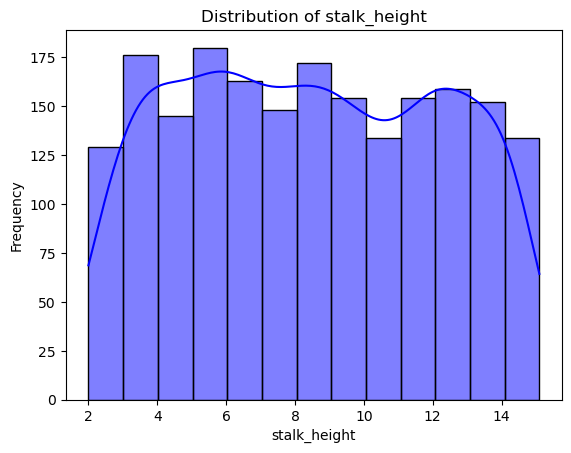

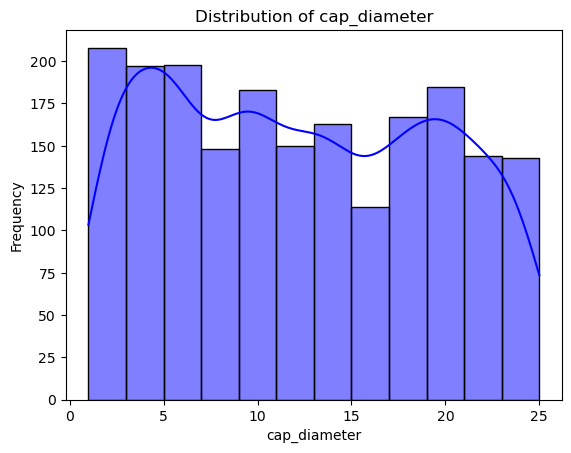

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

for cols in numerical_cols:
    sns.histplot(df[cols],color='blue',edgecolor='black',kde=True)
    plt.title(f'Distribution of {cols}')
    plt.xlabel(cols)
    plt.ylabel("Frequency")
    plt.show()

The most frequent stalk height among mushrooms is around 5 units, indicated by the tallest bar in the histogram.

The least frequent stalk height is around 2 units, showing that very few mushrooms have that small stalk.

A large number of mushrooms have cap diameter around 1 unit, making it the most common size.

Very few mushrooms have cap diameters near 15 or above.

BoxPlot:

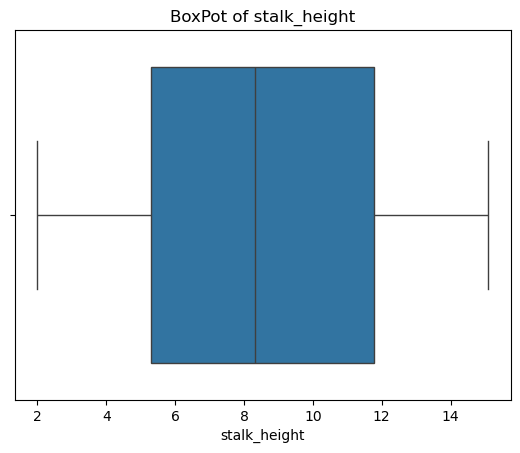

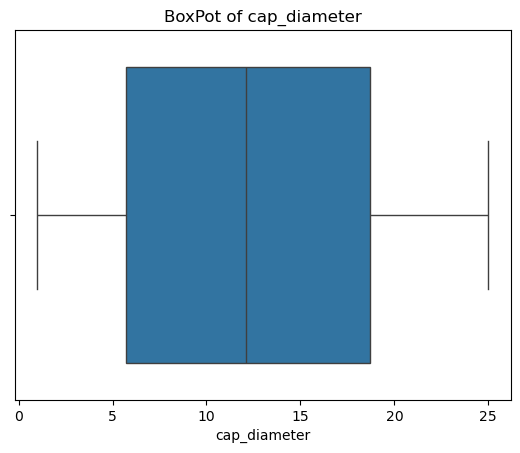

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

for cols in numerical_cols:
    sns.boxplot(x=df[cols])
    plt.title(f'BoxPot of {cols}')
    
    plt.show()

Both the boxplots doesnot reveal significant outliers.

Density Plot:

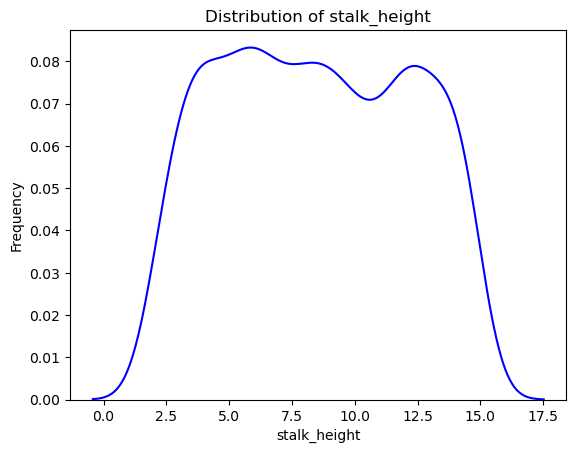

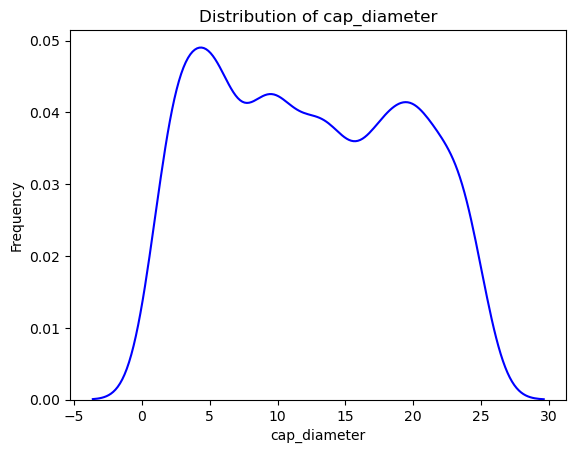

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

for cols in numerical_cols:
    sns.kdeplot(df[cols],color='blue')
    plt.title(f'Distribution of {cols}')
    plt.xlabel(cols)
    plt.ylabel("Frequency")
    plt.show()

stalk_height:        
The curve is roughly symmetric, suggesting that the feature is normally distributed.

cap_diameter:           
This indicates a slight left skew (negative skewness).

3.	Investigate feature correlations to discern relationships within the data.

In [32]:
correlation_matrix=df.corr(numeric_only=True)

In [33]:
correlation_matrix

,stalk_height,cap_diameter
stalk_height,1.000000,-0.003486
cap_diameter,-0.003486,1.000000


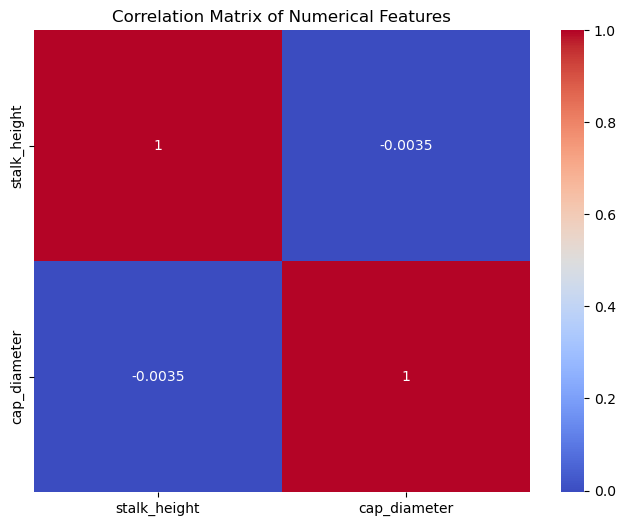

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

• The correlation matrix between numerical features shows that stalk_height and cap_diameter have a very weak negative correlation of approximately -0.003.

• This indicates that there is almost no linear relationship between these two features.




Task 2: Data Preprocessing

1.	Encode categorical variables if necessary.

In [38]:
categorical_cols=df.select_dtypes('object').columns

In [39]:
categorical_cols

Index(['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor',
       'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class'],
      dtype='object')

In [40]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le=LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])



In [41]:
df_encoded

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,4,2,7,0,1,1,2,0,7,1,...,0,0,2,6,3,1,5,1,14.276173,5.054983
1,4,0,6,0,1,3,1,1,3,0,...,1,0,2,6,1,2,5,0,3.952715,19.068319
2,3,1,5,1,4,1,1,0,8,1,...,1,3,2,6,6,0,5,1,9.054265,7.205884
3,0,2,4,1,3,3,0,0,6,0,...,0,3,2,0,4,1,0,1,5.226499,20.932692
4,3,3,8,1,5,2,1,1,6,0,...,1,2,0,4,8,1,4,1,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4,2,0,1,4,0,1,1,3,1,...,0,1,1,2,6,0,1,1,5.877891,17.464145
1996,4,2,5,1,5,0,2,1,9,1,...,0,2,1,7,8,2,5,1,6.500840,13.501957
1997,2,1,3,1,3,3,0,1,7,1,...,0,0,2,1,8,0,6,1,13.558064,11.270020
1998,0,3,7,0,7,2,0,1,6,0,...,1,3,1,0,1,5,6,1,11.092703,8.423199


Since all the faetures are non-ordinal we applied Label Encoding on each faeture.

2.	Split the dataset into training and testing sets.

In [44]:
x=df_encoded.drop('class',axis=1)

In [45]:
y=df_encoded['class']

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Task 3: Data Visualization

1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

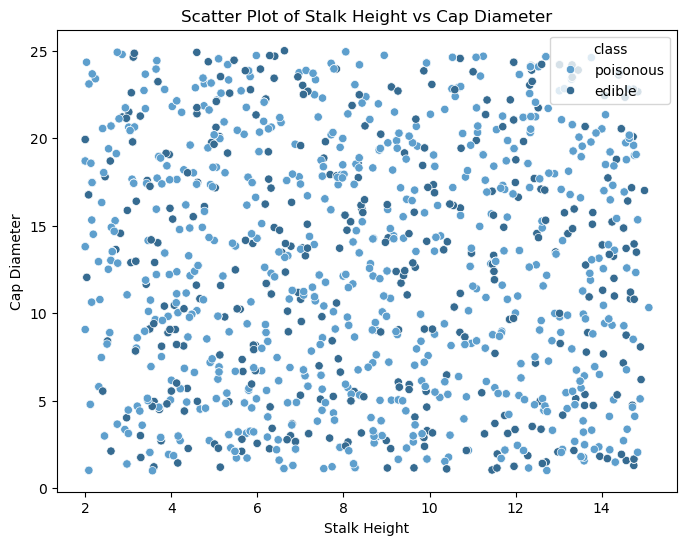

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='stalk_height', y='cap_diameter', hue='class', palette='Blues_d')
plt.title('Scatter Plot of Stalk Height vs Cap Diameter')
plt.xlabel('Stalk Height')
plt.ylabel('Cap Diameter')
plt.show()


The scatter plot shows that edible and poisonous mushrooms are scattered without any clear separation based on stalk height and cap diameter. Both classes overlap significantly, indicating no distinct clusters or linear patterns. 

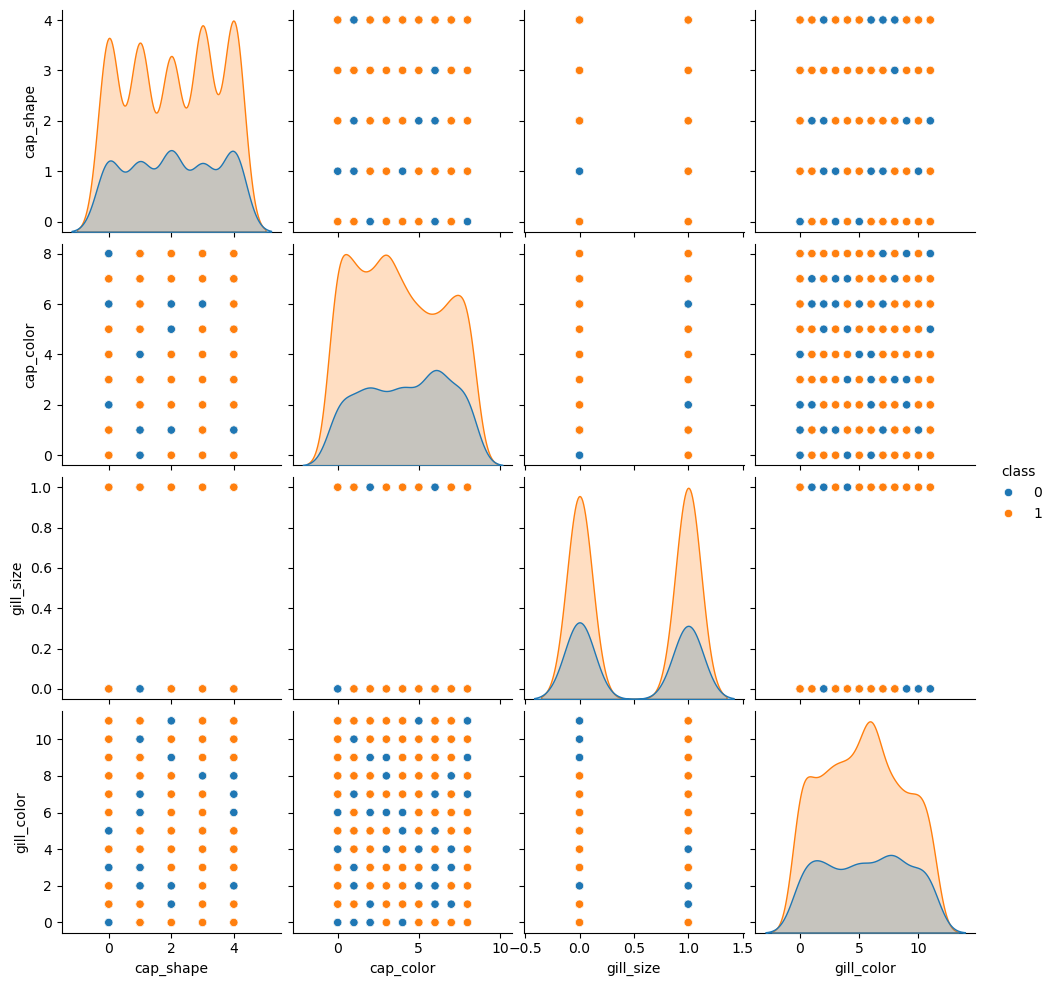

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = ['cap_shape', 'cap_color', 'gill_size', 'gill_color', 'class']
sns.pairplot(df_encoded[selected_features], hue='class')
plt.show()


The pair plot visualizes the relationships between the features cap_shape, cap_color, gill_size, and gill_color for the mushroom dataset.

From the plots, there is no clear linear separation between the edible (class 0) and poisonous (class 1) mushrooms for most feature pairs. However, gill_size shows a noticeable pattern: class 1 (poisonous) mushrooms are more concentrated in one value range, whereas class 0 (edible) mushrooms are more frequent in another. 

2.	Visualize class distributions to gauge dataset balance or imbalance.

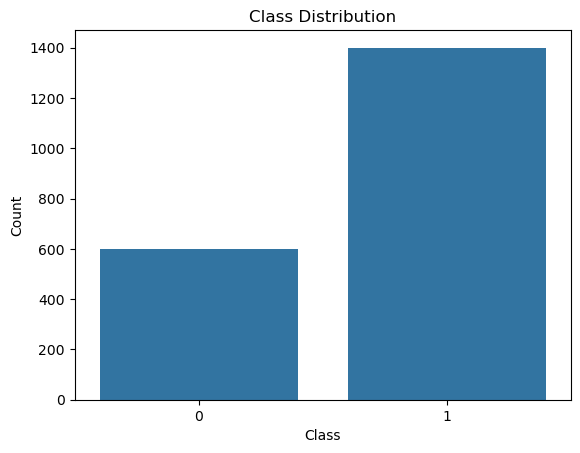

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='class',data=df_encoded)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()



The dataset is imbalanced, with Class 0 having around 600 instances and Class 1 having over 1400 instances.

Task 4: SVM Implementation

1.	Implement a basic SVM classifier using Python libraries like scikit-learn.

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
from sklearn.svm import SVC

In [61]:
svm=SVC()

2.	Train the SVM model on the training data.

In [63]:
svm.fit(x_train,y_train)

SVC()

In [64]:
y_pred=svm.predict(x_test)

3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [66]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [67]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.6675


In [68]:
print("Precision Score:",precision_score(y_test,y_pred))

Precision Score: 0.6675


In [69]:
print("Recall Score:",recall_score(y_test,y_pred))

Recall Score: 1.0


In [70]:
print("F1 Score:",f1_score(y_test,y_pred))

F1 Score: 0.800599700149925


The SVM model achieved an accuracy of 66.75%, with a precision of 66.75%, a perfect recall of 100%, and an F1-score of 0.8006. This indicates that while the model successfully identified all positive cases (high recall), it had some false positives, which lowered its precision and overall accuracy.

Task 5: Visualization of SVM Results

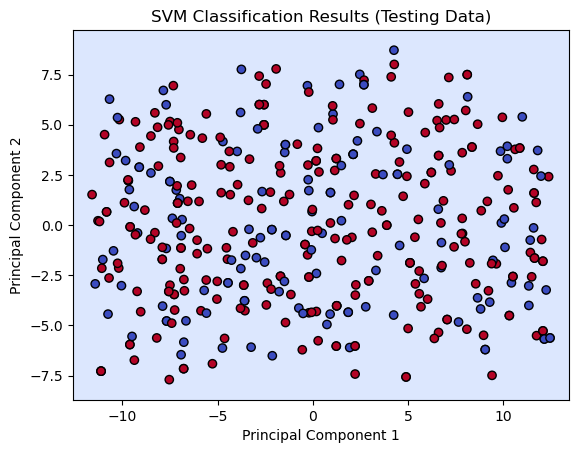

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Reduce features to 2D for visualization
pca = PCA(n_components=2)
x_test_2D = pca.fit_transform(x_test)
x_train_2D = pca.transform(x_train)

# Train model again on reduced features for visualization
svm_model_vis = SVC(kernel='linear')
svm_model_vis.fit(x_train_2D, y_train)

# Create meshgrid for decision boundary
x_min, x_max = x_test_2D[:, 0].min() - 1, x_test_2D[:, 0].max() + 1
y_min, y_max = x_test_2D[:, 1].min() - 1, x_test_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict for each point in meshgrid
Z = svm_model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary and points
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_test_2D[:, 0], x_test_2D[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title('SVM Classification Results (Testing Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


From the visualization, we can see that the classes are spread across the feature space without a clearly separable linear boundary in 2D PCA space, which could explain why the model’s accuracy (~66.75%) is not very high.

Some overlap exists between red and blue points, indicating misclassifications.

Task 6: Parameter Tuning and Optimization

1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [77]:
from sklearn.model_selection import  GridSearchCV

In [78]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

In [79]:
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')

In [126]:
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             verbose=2)

In [130]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


In [132]:
print("Best score:", grid_search.best_score_)

Best score: 0.8381197986569321


The RBF kernel with C=1 and gamma='auto' gave the best accuracy (~83.8%) during model tuning.

Task 7: Comparison and Analysis

1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

In [161]:
import warnings
warnings.filterwarnings('ignore')

In [167]:
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

# Kernels to compare
kernels = ['linear', 'poly', 'rbf']

results = []

for kernel in kernels:
    clf = svm.SVC(kernel=kernel)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Kernel': kernel,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f"\nKernel: {kernel}")
    print(classification_report(y_test, y_pred))





Kernel: linear
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400


Kernel: poly
              precision    recall  f1-score   support

           0       1.00      0.08      0.14       133
           1       0.68      1.00      0.81       267

    accuracy                           0.69       400
   macro avg       0.84      0.54      0.48       400
weighted avg       0.79      0.69      0.59       400


Kernel: rbf
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.

Linear Kernel:           
Achieved an accuracy of 67%, with perfect recall for class 1 but failing to correctly classify any instances of class 0.

Polynomial Kernel:        
Produced the highest accuracy of 69% among the tested kernels. It managed to identify most class 1 instances correctly while capturing a small portion of class 0.

RBF Kernel:                       
Performance was almost identical to the linear kernel (67% accuracy), with the same issue of predicting only class 1 correctly.



2.	Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.

- Strengths:

 - Handles High-Dimensional Data Well:
The mushroom dataset, after encoding, becomes high-dimensional. SVM can effectively find decision boundaries in such feature spaces.

 - Good Performance with Clear Separation:
The classes in the mushroom dataset (edible vs. poisonous) are well-separated, which aligns with SVM’s strength in finding maximum-margin hyperplanes.

 - Flexibility via Kernels:
Different kernels (linear, RBF, polynomial) allow SVM to adapt to both linear and non-linear patterns in the dataset.

 - Robust to Overfitting in High-Dimensional Space:
With proper regularization (C parameter), SVM maintains good generalization.

- Weaknesses:

 - Computational Cost:
SVM can be slow on large datasets. Even with 2,000 rows, non-linear kernels take more time compared to simpler models like Logistic Regression.

 - Sensitive to Parameter Tuning:
Kernel type, C, and gamma require careful tuning; poor choices can lead to underfitting or overfitting.

 - Limited Probability Output:
SVM does not naturally provide probability scores (needs extra computation with probability=True).

 - Interpretability:
The model’s decision boundary and feature influence are less interpretable compared to tree-based methods.

3.	Discuss practical implications of SVM in real-world classification tasks.

- Medical Diagnosis – SVM is effective in identifying diseases such as cancer (e.g., classifying tumor cells as malignant or benign) using patient medical records and imaging data. Its ability to work well with high-dimensional features makes it suitable for complex biomedical datasets.

- Text and Document Classification – SVM is frequently applied in spam detection, sentiment analysis, and topic categorization due to its efficiency in handling sparse and high-dimensional data from text processing.

- Image Recognition – It is used for tasks like face detection, handwriting recognition, and object classification, where feature dimensions are large, and clear decision boundaries are required.

- Bioinformatics – SVM plays a crucial role in gene classification, protein structure prediction, and classification of bio-sequences, where datasets are often small but with high feature counts.

- Financial Risk Assessment – Banks and financial institutions use SVM to classify credit risk levels, detect fraud, and predict loan defaults based on customer profiles.